In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Maternal Health Risk Data Set.csv")

In [3]:
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


In [4]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [5]:
# Before beginning any analysis, I verified the dataset quality by checking for missing values and data completeness. Fortunately, the dataset was complete, allowing me to focus directly on exploratory analysis and feature understanding.

In [6]:
# Shape of Dataset
print("Rows and Columns:", df.shape)

# Column Information
print(df.info())

# First Five Rows
df.head()

Rows and Columns: (1014, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB
None


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [7]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


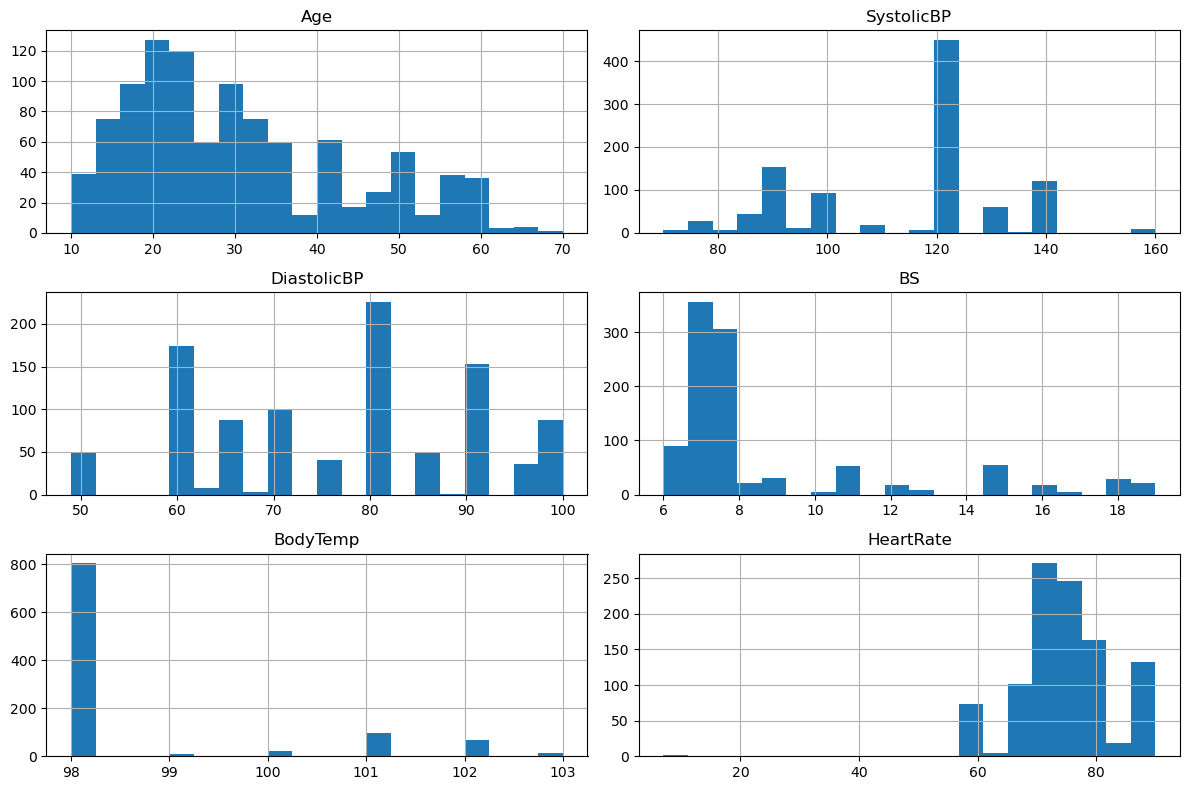

In [7]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8), bins=20)

plt.tight_layout()

plt.show()

In [8]:
print(df["RiskLevel"].value_counts())

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_35552\3513145043.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


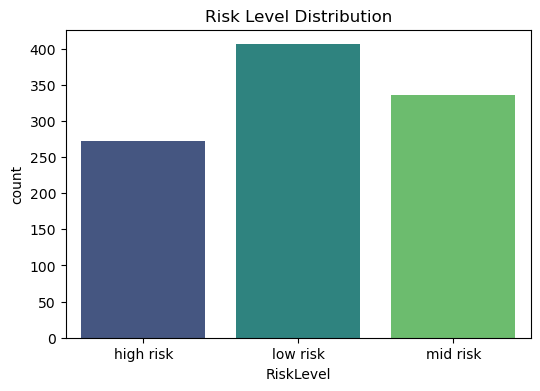

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="RiskLevel",
    palette="viridis"
)

plt.title("Risk Level Distribution")

plt.show()

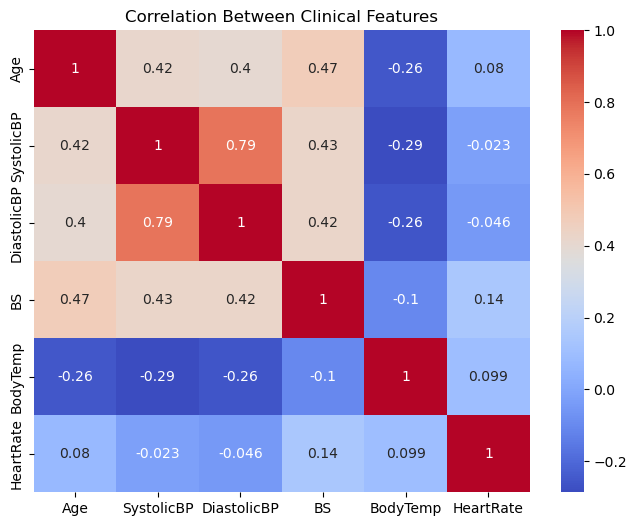

In [10]:
plt.figure(figsize=(8,6))

corr = df.drop("RiskLevel", axis=1).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Clinical Features")

plt.show()

✅ Feature 1 — Pulse Pressure
Medical Meaning

Pulse Pressure = SystolicBP − DiastolicBP

High pulse pressure can indicate cardiovascular issues.

In [11]:
df["PulsePressure"] = df["SystolicBP"] - df["DiastolicBP"]

df[["SystolicBP","DiastolicBP","PulsePressure"]].head()

,SystolicBP,DiastolicBP,PulsePressure
0,130,80,50
1,140,90,50
2,90,70,20
3,140,85,55
4,120,60,60


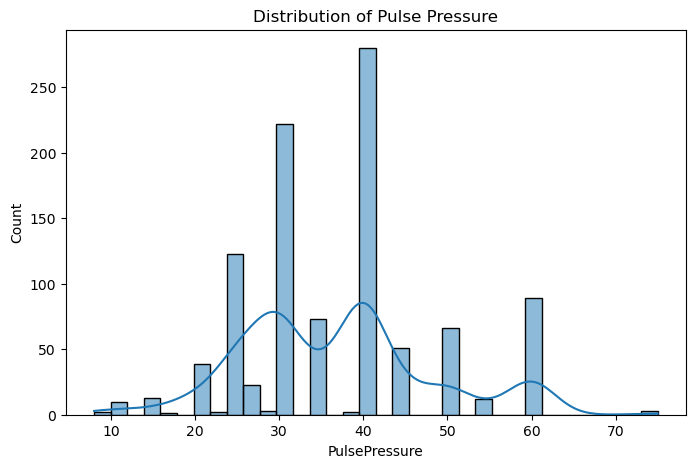

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["PulsePressure"], kde=True)

plt.title("Distribution of Pulse Pressure")

plt.show()

✅ Feature 2 — Mean Arterial Pressure (MAP)

Doctors often use MAP instead of just BP.

Formula

MAP = (Systolic + 2 × Diastolic) / 3

In [13]:
df["MAP"] = (df["SystolicBP"] + 2*df["DiastolicBP"]) / 3

df[["MAP"]].head()

,MAP
0,96.666667
1,106.666667
2,76.666667
3,103.333333
4,80.000000


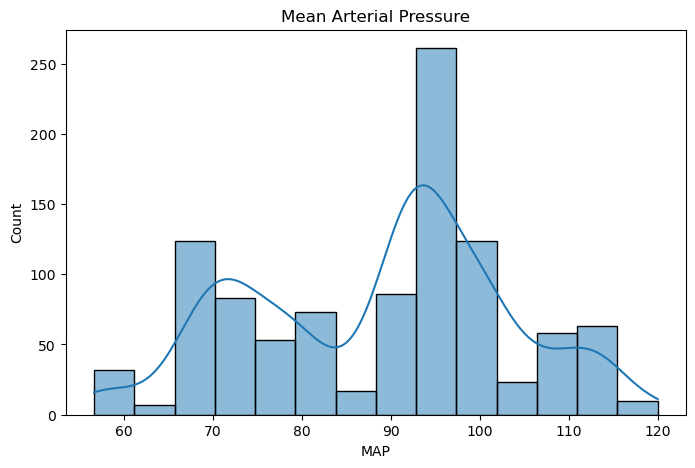

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["MAP"], kde=True)

plt.title("Mean Arterial Pressure")

plt.show()

✅ Feature 3 — Fever Indicator

Normal Body Temperature ≈ 98.6°F

Create:

0 = Normal

1 = Fever

In [15]:
df["Fever"] = np.where(df["BodyTemp"] >= 99.5,1,0)

df[["BodyTemp","Fever"]].head()

,BodyTemp,Fever
0,98.0,0
1,98.0,0
2,100.0,1
3,98.0,0
4,98.0,0


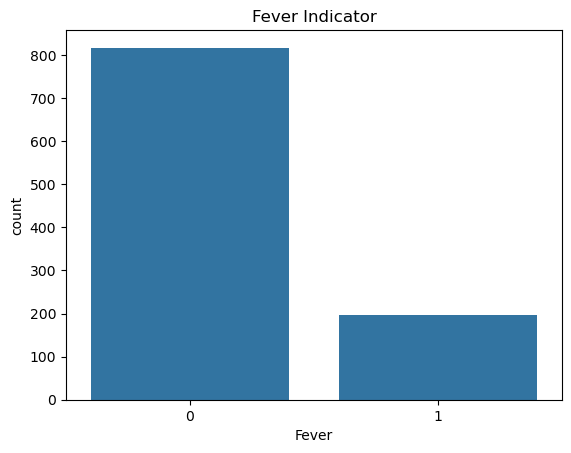

In [16]:
sns.countplot(data=df,x="Fever")

plt.title("Fever Indicator")

plt.show()

✅ Feature 4 — High Blood Sugar

In [17]:
df["HighBS"] = np.where(df["BS"] >= 7,1,0)

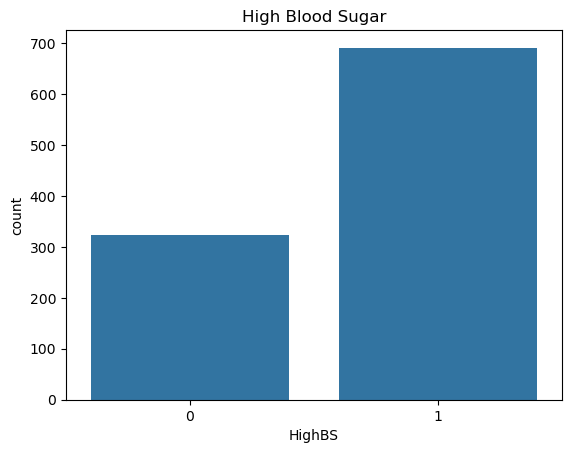

In [18]:
sns.countplot(data=df,x="HighBS")

plt.title("High Blood Sugar")

plt.show()

✅ Feature 5 — Age Group

Instead of exact age

In [19]:
bins = [10,20,30,40,50,60]

labels = ["Teen","20-30","30-40","40-50","50+"]

df["AgeGroup"] = pd.cut(df["Age"],
                        bins=bins,
                        labels=labels)

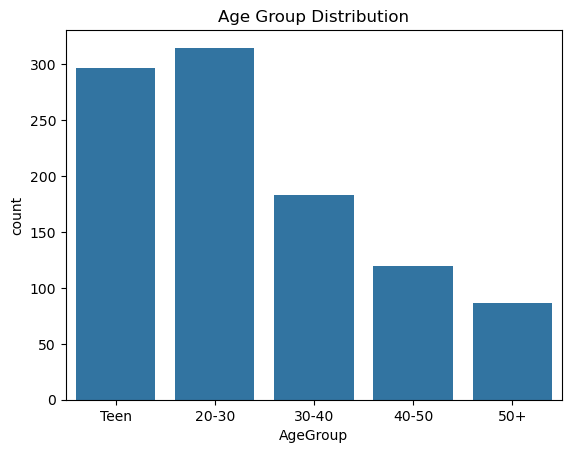

In [20]:
sns.countplot(data=df,
              x="AgeGroup")

plt.title("Age Group Distribution")

plt.show()

✅ Feature 6 — Blood Pressure Category

In [21]:
def bp_category(bp):

    if bp < 120:
        return "Normal"

    elif bp < 140:
        return "Elevated"

    else:
        return "High"

df["BP_Category"] = df["SystolicBP"].apply(bp_category)

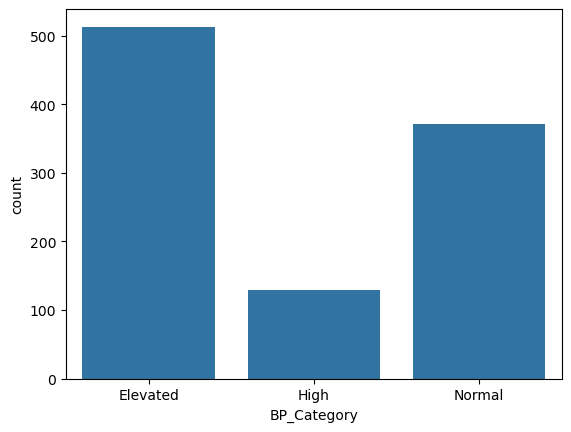

In [22]:
sns.countplot(data=df,
              x="BP_Category")

plt.show()

✅ Feature 7 — Heart Rate Category

In [23]:
def hr_category(hr):

    if hr < 60:
        return "Low"

    elif hr <=100:
        return "Normal"

    else:
        return "High"

df["HR_Category"] = df["HeartRate"].apply(hr_category)

📊 Compare Before vs After

print("Original Features:",6)

print("New Features:",len(df.columns)-1)

In [24]:
print(df.columns)

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel', 'PulsePressure', 'MAP', 'Fever', 'HighBS', 'AgeGroup',
       'BP_Category', 'HR_Category'],
      dtype='object')


📊 Correlation After Feature Engineering

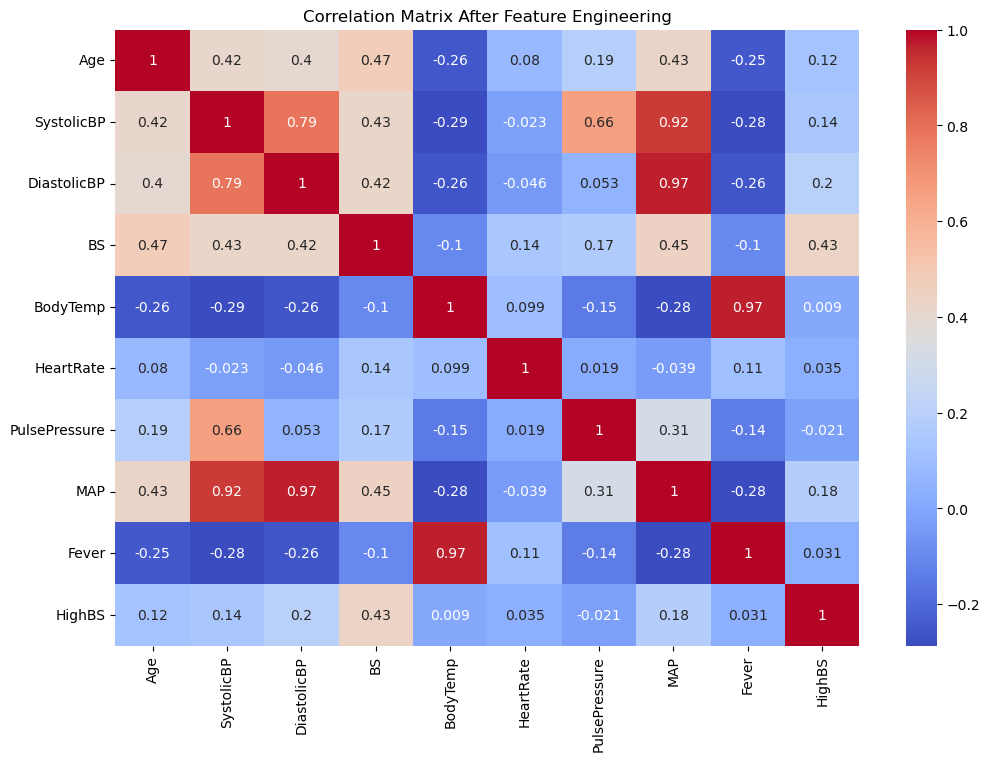

In [25]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix After Feature Engineering")

plt.show()

📁 Save New Dataset

In [26]:
df.to_csv(
    "maternal_health_feature_engineered.csv",
    index=False
)

In [27]:
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,PulsePressure,MAP,Fever,HighBS,AgeGroup,BP_Category,HR_Category
0,25,130,80,15.0,98.0,86,high risk,50,96.666667,0,1,20-30,Elevated,Normal
1,35,140,90,13.0,98.0,70,high risk,50,106.666667,0,1,30-40,High,Normal
2,29,90,70,8.0,100.0,80,high risk,20,76.666667,1,1,20-30,Normal,Normal
3,30,140,85,7.0,98.0,70,high risk,55,103.333333,0,1,20-30,High,Normal
4,35,120,60,6.1,98.0,76,low risk,60,80.000000,0,0,30-40,Elevated,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk,60,80.000000,0,1,20-30,Elevated,Normal
1010,55,120,90,18.0,98.0,60,high risk,30,100.000000,0,1,50+,Elevated,Normal
1011,35,85,60,19.0,98.0,86,high risk,25,68.333333,0,1,30-40,Normal,Normal
1012,43,120,90,18.0,98.0,70,high risk,30,100.000000,0,1,40-50,Elevated,Normal


In [28]:

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("maternal_health_feature_engineered.csv")

In [30]:
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,PulsePressure,MAP,Fever,HighBS,AgeGroup,BP_Category,HR_Category
0,25,130,80,15.0,98.0,86,high risk,50,96.666667,0,1,20-30,Elevated,Normal
1,35,140,90,13.0,98.0,70,high risk,50,106.666667,0,1,30-40,High,Normal
2,29,90,70,8.0,100.0,80,high risk,20,76.666667,1,1,20-30,Normal,Normal
3,30,140,85,7.0,98.0,70,high risk,55,103.333333,0,1,20-30,High,Normal
4,35,120,60,6.1,98.0,76,low risk,60,80.000000,0,0,30-40,Elevated,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk,60,80.000000,0,1,20-30,Elevated,Normal
1010,55,120,90,18.0,98.0,60,high risk,30,100.000000,0,1,50+,Elevated,Normal
1011,35,85,60,19.0,98.0,86,high risk,25,68.333333,0,1,30-40,Normal,Normal
1012,43,120,90,18.0,98.0,70,high risk,30,100.000000,0,1,40-50,Elevated,Normal


Encode Target Variable
Your target is - 
RiskLevel

Result
Low = 0
Mid = 1
High = 2

In [31]:
le = LabelEncoder()

df["RiskLevel"] = le.fit_transform(df["RiskLevel"])

Convert Categories

In [44]:
df = pd.get_dummies(df, drop_first=True)

Split Dataset

In [33]:
X = df.drop("RiskLevel", axis=1)

y = df["RiskLevel"]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

Train Random Forest

In [34]:
model = RandomForestClassifier(

    n_estimators=200,

    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Prediction

In [35]:
pred = model.predict(X_test)

Accuracy

In [36]:
accuracy = accuracy_score(y_test, pred)

print("Accuracy :", accuracy)

Accuracy : 0.8571428571428571


In [37]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        55
           1       0.89      0.80      0.84        81
           2       0.77      0.87      0.82        67

    accuracy                           0.86       203
   macro avg       0.86      0.87      0.86       203
weighted avg       0.86      0.86      0.86       203



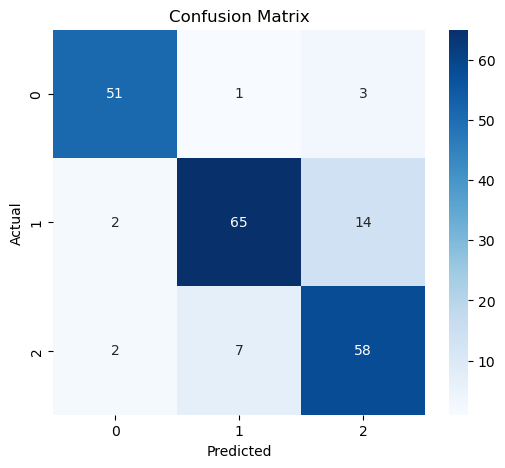

In [38]:
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [39]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

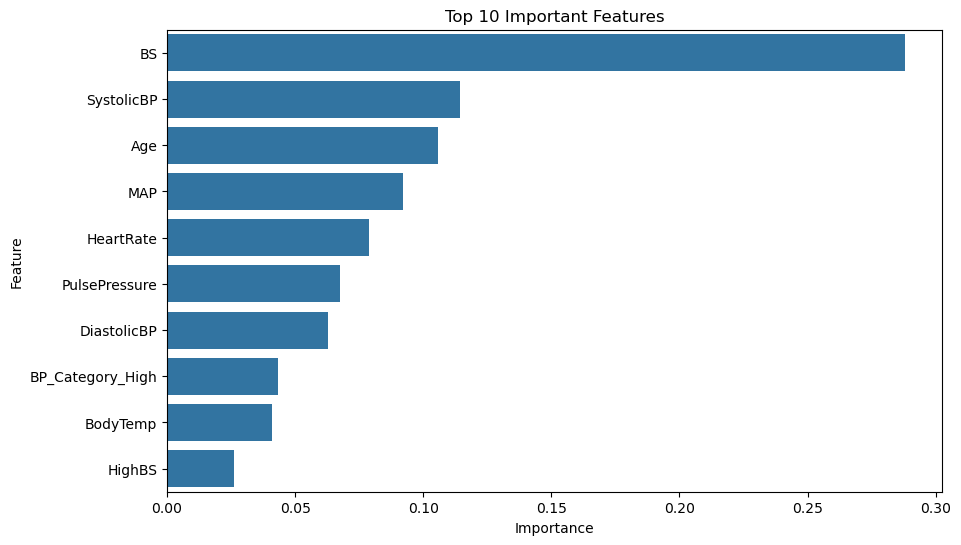

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Top 10 Important Features")

plt.show()

In [41]:
import joblib

joblib.dump(

    model,

    "maternal_health_model.pkl"

)

['maternal_health_model.pkl']

In [1]:
import os
os.getcwd()

'C:\\Users\\HP'

In [2]:
os.listdir()

['.anaconda',
 '.conda',
 '.condarc',
 '.continuum',
 '.copilot',
 '.ghcp-appmod',
 '.ipynb_checkpoints',
 '.ipython',
 '.jdks',
 '.junie',
 '.jupyter',
 '.m2',
 '.matplotlib',
 '.spyder-py3',
 '.VirtualBox',
 '.vscode',
 '01_front.jpg',
 '02_tilt_left.jpg',
 '03_tilt_right.jpg',
 '04_top_view.jpg',
 '05_bottom_view.jpg',
 '06_close.jpg',
 '07_far.jpg',
 '08_left_side.jpg',
 '09_right_side.jpg',
 '1. Weather Data.csv',
 '10_diagonal.jpg',
 '16_F1_Race_Results_2019_2024.csv',
 '2. Cars Data1.csv',
 '4. Covid_19_data.csv',
 'abalone.data',
 'Abalone_age_prediction.ipynb',
 'anaconda3',
 'ansel',
 'AppData',
 'Application Data',
 'asha_model_final .ipynb',
 'batsman_runs_ipl.csv',
 'benzene avag..cml',
 'best_model.joblib',
 'Binning-and-Discretization.ipynb',
 'bollywood.csv',
 'bouncing_ball.gif',
 'callibration_img',
 'Callibration_img.ipynb',
 'comp phy.py',
 'Comp.Physics.ipynb',
 'concrete_data.csv',
 'Contacts',
 'Cookies',
 'cpp 1.cpp',
 'Crop_yield_prediction.ipynb',
 'cse class.